In [26]:
%pip install matplotlib
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
N = 50                # Length of the polymer (number of monomers)
num_steps = 5000000      # Total number of Monte Carlo steps
bond_length = 1.0     # Fixed bond length between monomers
dimension = 3         # 3D space
window_size = 100000     # Size of sliding window for R_g averaging
equilibration_window_size = 10000  # Number of steps in the window for equilibration check
equilibration_tolerance = 0.1  # Tolerance for relative change (e.g., 1%)
nu_values = np.arange(0.4, 0.6, 0.1)  # Range of nu values from 0.3 to 0.8 in steps of 0.1


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [19]:
def initialize_polymer(N, dimension, bond_length):
    """Initialize polymer with fixed bond length."""
    polymer = np.zeros((N, dimension))
    for i in range(1, N):
        while True:
            # Random step of fixed bond length
            step = np.random.normal(size=dimension)
            step = step / np.linalg.norm(step) * bond_length  # Normalize to fixed length
            new_position = polymer[i - 1] + step

            # Check for self-avoidance
            if not any(np.linalg.norm(new_position - polymer[j]) < bond_length for j in range(i)):
                polymer[i] = new_position
                break
    return polymer

def compute_radius_of_gyration(polymer):
    """Calculate the radius of gyration R_g for the polymer configuration."""
    N = len(polymer)
    center_of_mass = np.mean(polymer, axis=0)
    rg_squared = np.sum((polymer - center_of_mass) ** 2) / N
    return np.sqrt(rg_squared)

def monte_carlo_step(polymer, nu):
    """Perform a Monte Carlo move with fixed bond length and self-avoidance."""
    N = len(polymer)
    # Pick a random monomer to move
    i = np.random.randint(1, N - 1)  # avoid moving the endpoints for simplicity
    old_position = polymer[i].copy()

    # Attempt a small random displacement
    displacement = np.random.normal(scale=0.1, size=dimension)
    new_position = old_position + displacement

    # Enforce fixed bond length with neighbors
    if (
        np.isclose(np.linalg.norm(new_position - polymer[i - 1]), bond_length, atol=0.1)
        and np.isclose(np.linalg.norm(new_position - polymer[i + 1]), bond_length, atol=0.1)
    ):
        # Check for self-avoidance
        if not any(np.linalg.norm(new_position - polymer[j]) < bond_length for j in range(N) if j != i):
            # Accept the move if all conditions are satisfied
            polymer[i] = new_position

    return polymer


def run_simulation(N, num_steps, nu, window_size=100, pdf_sample_size=500, update_interval=100, initial_conformation=None):
    """
    Runs a Monte Carlo simulation of a polymer chain in solution with real-time display.

    Parameters:
    - N (int): Number of monomers in the polymer chain.
    - num_steps (int): Total number of Monte Carlo steps.
    - nu (float): Flory parameter representing solvent quality.
    - window_size (int): Size of the sliding window for R_g averaging.
    - pdf_sample_size (int): Number of recent R_g values to use for PDF calculation.
    - update_interval (int): Number of steps between plot updates.
    - initial_conformation (np.ndarray): Optional initial polymer configuration.

    Returns:
    - final_polymer (np.ndarray): Final polymer conformation at the end of the simulation.
    - mean_rg (float): Mean R_g after equilibration.
    - variance_rg (float): Variance of R_g after equilibration.
    - rg_list (list): List of all R_g values for plotting.
    """
    # Initialize polymer and variables for tracking radius of gyration
    polymer = initial_conformation if initial_conformation is not None else initialize_polymer(N, dimension, bond_length)
    rg_list = []
    rg_window_mean = []
    rg_variance_list = []  # Track variance of R_g

    # Equilibration check variables
    equilibrated = False
    equilibration_step = 0

    # Set up real-time plots
    plt.ion()  # Turn on interactive mode
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.set_title("Radius of Gyration (R_g) over Steps")
    ax1.set_xlabel("Simulation Steps")
    ax1.set_ylabel("Radius of Gyration (R_g)")
    line1, = ax1.plot([], [], label="R_g")

    ax2.set_title("Variance of R_g over Steps")
    ax2.set_xlabel("Simulation Steps")
    ax2.set_ylabel("Variance of R_g")
    line2, = ax2.plot([], [], label="Variance of R_g")
    ax1.legend()
    ax2.legend()

    for step in range(num_steps):
        polymer = monte_carlo_step(polymer, nu)
        rg = compute_radius_of_gyration(polymer)
        rg_list.append(rg)

        # Equilibration check
        if not equilibrated and len(rg_list) >= equilibration_window_size:
            recent_rg = rg_list[-equilibration_window_size:]
            mean_rg = np.mean(recent_rg)
            max_rg = np.max(recent_rg)
            min_rg = np.min(recent_rg)
            relative_change = (max_rg - min_rg) / mean_rg
            
            if relative_change < equilibration_tolerance:
                equilibrated = True
                equilibration_step = step
                print(f"Equilibrated at step {step} with relative change {relative_change:.4f}")

        # Calculate and store variance of R_g after equilibration
        if equilibrated:
            if len(rg_list) >= window_size:
                rg_variance = np.var(rg_list[-window_size:])
                rg_variance_list.append(rg_variance)

        # Update plots every `update_interval` steps
        if step % update_interval == 0 and equilibrated:
            # Update R_g plot
            line1.set_data(range(len(rg_list)), rg_list)
            ax1.relim()
            ax1.autoscale_view()

            # Update variance plot
            line2.set_data(range(len(rg_variance_list)), rg_variance_list)
            ax2.relim()
            ax2.autoscale_view()

            # Draw canvas for real-time update
            fig.canvas.draw()
            fig.canvas.flush_events()

        # Print progress every 100 steps
        if step % 100 == 0:
            print(f"Step: {step}, R_g: {rg:.4f}")

    # Calculate final statistics only on data after equilibration
    if equilibrated:
        final_mean_rg = np.mean(rg_list[equilibration_step:])
        final_variance_rg = np.var(rg_list[equilibration_step:])
    else:
        final_mean_rg = np.mean(rg_list)
        final_variance_rg = np.var(rg_list)

    # Turn off interactive plotting mode and show final plots
    plt.ioff()
    plt.show()

    # Return the final polymer conformation, mean R_g, variance of R_g, and all R_g values
    return polymer, final_mean_rg, final_variance_rg, rg_list

Step: 0, R_g: 4.4324
Step: 100, R_g: 4.4325
Step: 200, R_g: 4.4378
Step: 300, R_g: 4.4456
Step: 400, R_g: 4.4538
Step: 500, R_g: 4.4609
Step: 600, R_g: 4.4625
Step: 700, R_g: 4.4647
Step: 800, R_g: 4.4665
Step: 900, R_g: 4.4663
Step: 1000, R_g: 4.4681
Step: 1100, R_g: 4.4695
Step: 1200, R_g: 4.4735
Step: 1300, R_g: 4.4683
Step: 1400, R_g: 4.4741
Step: 1500, R_g: 4.4722
Step: 1600, R_g: 4.4682
Step: 1700, R_g: 4.4656
Step: 1800, R_g: 4.4669
Step: 1900, R_g: 4.4585
Step: 2000, R_g: 4.4601
Step: 2100, R_g: 4.4656
Step: 2200, R_g: 4.4694
Step: 2300, R_g: 4.4657
Step: 2400, R_g: 4.4541
Step: 2500, R_g: 4.4551
Step: 2600, R_g: 4.4609
Step: 2700, R_g: 4.4656
Step: 2800, R_g: 4.4690
Step: 2900, R_g: 4.4629
Step: 3000, R_g: 4.4624
Step: 3100, R_g: 4.4597
Step: 3200, R_g: 4.4610
Step: 3300, R_g: 4.4634
Step: 3400, R_g: 4.4598
Step: 3500, R_g: 4.4550
Step: 3600, R_g: 4.4534
Step: 3700, R_g: 4.4546
Step: 3800, R_g: 4.4609
Step: 3900, R_g: 4.4581
Step: 4000, R_g: 4.4576
Step: 4100, R_g: 4.4594
Step

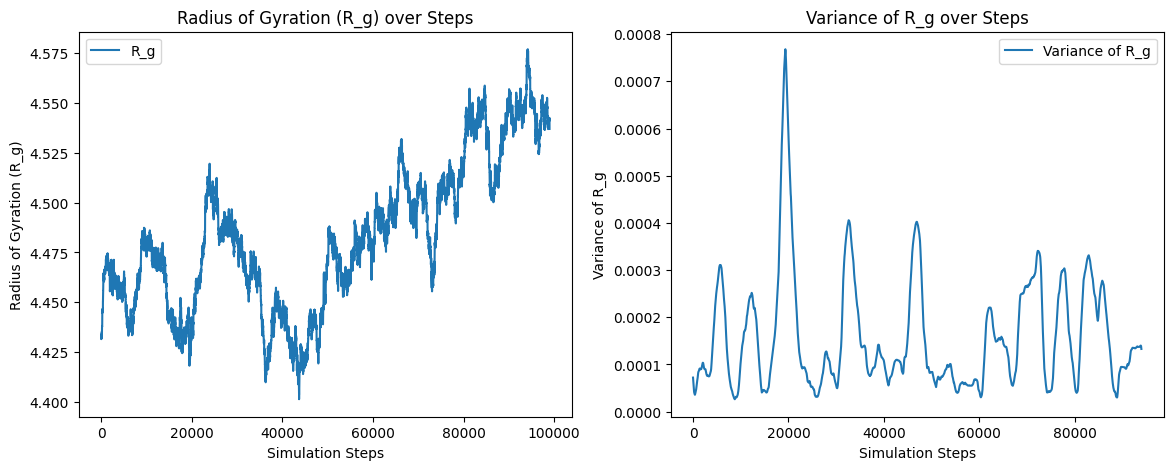

In [20]:
# test one polymer
final_polymer, mean_rg, variance_rg, rg_data = run_simulation(N, num_steps, nu=0.5, window_size=window_size, pdf_sample_size=10000, update_interval=1000)

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Parameters
# N = 10                # Fixed length of the polymer (number of monomers)
# num_steps = 100000      # Total number of Monte Carlo steps
# window_size = 1000    # Size of sliding window for R_g averaging
# equilibration_window_size = 1000  # Number of steps in the window for equilibration check
# equilibration_tolerance = 0.5  # Tolerance for relative change (e.g., 1%)
# nu_values = np.arange(0.5, 0.8, 0.1)  # Range of nu values from 0.3 to 0.8 in steps of 0.1

# # Define the function to run a single simulation
# def run_simulation(N, num_steps, nu, window_size=100, initial_conformation=None):
#     """
#     Runs a Monte Carlo simulation of a polymer chain in solution.

#     Parameters:
#     - N (int): Number of monomers in the polymer chain.
#     - num_steps (int): Total number of Monte Carlo steps.
#     - nu (float): Flory parameter representing solvent quality.
#     - window_size (int): Size of the sliding window for R_g averaging.
#     - initial_conformation (np.ndarray): Optional initial polymer configuration.

#     Returns:
#     - final_polymer (np.ndarray): Final polymer conformation at the end of the simulation.
#     - final_mean_rg (float): Mean R_g after equilibration.
#     - final_variance_rg (float): Variance of R_g after equilibration.
#     - rg_list (list): List of all R_g values.
#     - rg_window_mean (list): List of windowed mean R_g values for plotting.
#     """
#     # Initialize polymer and variables for tracking radius of gyration
#     polymer = initial_conformation if initial_conformation is not None else initialize_polymer(N, dimension)
#     rg_list = []
#     rg_window_mean = []

#     # Equilibration check variables
#     equilibrated = False
#     equilibration_step = 0

#     # Monte Carlo simulation with R_g printout
#     for step in range(num_steps):
#         polymer = monte_carlo_step(polymer, nu)

#         # Compute and store R_g
#         rg = compute_radius_of_gyration(polymer)
#         rg_list.append(rg)

#         # Check for equilibration
#         if not equilibrated and len(rg_list) >= equilibration_window_size:
#             # Calculate mean and range within the window
#             recent_rg_values = rg_list[-equilibration_window_size:]
#             mean_rg = np.mean(recent_rg_values)
#             max_rg = np.max(recent_rg_values)
#             min_rg = np.min(recent_rg_values)

#             # Calculate relative change within the window
#             relative_change = (max_rg - min_rg) / mean_rg

#             # Check if the relative change is within the tolerance
#             if relative_change < equilibration_tolerance:
#                 equilibrated = True
#                 equilibration_step = step
#                 print(f"System has equilibrated at step {step} with relative change {relative_change:.4f}")

#         # Record R_g for analysis and windowed average if the system is equilibrated
#         if equilibrated:
#             if len(rg_list) >= window_size:
#                 windowed_mean_rg = np.mean(rg_list[-window_size:])
#                 rg_window_mean.append(windowed_mean_rg)

#                 # Print progress every 100 steps
#                 if step % 100 == 0:
#                     print(f"Step: {step}, R_g: {rg:.4f}, Windowed Mean R_g: {windowed_mean_rg:.4f}")

#     # Calculate final statistics only on data after equilibration
#     if equilibrated:
#         final_mean_rg = np.mean(rg_list[equilibration_step:])
#         final_variance_rg = np.var(rg_list[equilibration_step:])
#     else:
#         final_mean_rg = np.mean(rg_list)
#         final_variance_rg = np.var(rg_list)

#     # Return the final polymer conformation, mean R_g, variance of R_g, and data for plotting
#     return polymer, final_mean_rg, final_variance_rg, rg_list, rg_window_mean



In [23]:
def run_simulations_over_nu_range(nu_values, N, num_steps, window_size=1000, pdf_sample_size=10000):
    rg_means = []
    rg_variances = []

    for nu in nu_values:
        print(f"\nRunning simulation for nu = {nu}")
        final_polymer, mean_rg, variance_rg, rg_list = run_simulation(N, num_steps, nu, window_size=window_size, pdf_sample_size=pdf_sample_size)

        # Store results for R_g and variance
        rg_means.append(mean_rg)
        rg_variances.append(variance_rg)

        print(f"nu = {nu}: Mean R_g = {mean_rg:.4f}, Variance R_g = {variance_rg:.4f}")

        # Plot R_g (windowed mean) vs. steps for this nu
        plt.figure(figsize=(10, 5))
        plt.plot(rg_list, label=f'R_g over steps for nu={nu}')
        plt.xlabel("Simulation Steps")
        plt.ylabel("Radius of Gyration (R_g)")
        plt.title(f"Radius of Gyration (R_g) vs. Steps for nu = {nu}")
        plt.legend()
        plt.show()

        # Plot R_g probability distribution for this nu using the last `pdf_sample_size` values
        sample_for_pdf = rg_list[-pdf_sample_size:] if len(rg_list) >= pdf_sample_size else rg_list
        plt.figure(figsize=(8, 5))
        plt.hist(sample_for_pdf, bins=30, density=True, alpha=0.7, color="blue", edgecolor="black")
        plt.xlabel("Radius of Gyration (R_g)")
        plt.ylabel("Probability Density")
        plt.title(f"Probability Distribution of R_g for nu = {nu} (last {pdf_sample_size} steps)")
        plt.show()

    # Plot R_g vs. nu
    plt.figure(figsize=(10, 5))
    plt.plot(nu_values, rg_means, marker='o', linestyle='-', color='b', label='Mean R_g')
    plt.xlabel("Flory Parameter (nu)")
    plt.ylabel("Mean Radius of Gyration (R_g)")
    plt.title("Mean Radius of Gyration vs. Flory Parameter (nu)")
    plt.legend()
    plt.show()


    # Plot Variance of R_g vs. nu
    plt.figure(figsize=(10, 5))
    plt.plot(nu_values, rg_variances, marker='o', linestyle='-', color='r', label='Variance of R_g')
    plt.xlabel("Flory Parameter (nu)")
    plt.ylabel("Variance of Radius of Gyration")
    plt.title("Variance of Radius of Gyration vs. Flory Parameter (nu)")
    plt.legend()
    plt.show()



Running simulation for nu = 0.4
Step: 0, R_g: 4.0987
Step: 100, R_g: 4.0963
Step: 200, R_g: 4.0997
Step: 300, R_g: 4.0957
Step: 400, R_g: 4.0963
Step: 500, R_g: 4.0985
Step: 600, R_g: 4.0986
Step: 700, R_g: 4.0957
Step: 800, R_g: 4.0969
Step: 900, R_g: 4.0897
Step: 1000, R_g: 4.0903
Step: 1100, R_g: 4.0914
Step: 1200, R_g: 4.0917
Step: 1300, R_g: 4.0924
Step: 1400, R_g: 4.0921
Step: 1500, R_g: 4.0909
Step: 1600, R_g: 4.0839
Step: 1700, R_g: 4.0838
Step: 1800, R_g: 4.0912
Step: 1900, R_g: 4.0923
Step: 2000, R_g: 4.0998
Step: 2100, R_g: 4.0919
Step: 2200, R_g: 4.0940
Step: 2300, R_g: 4.0990
Step: 2400, R_g: 4.1016
Step: 2500, R_g: 4.0997
Step: 2600, R_g: 4.0953
Step: 2700, R_g: 4.0898
Step: 2800, R_g: 4.0858
Step: 2900, R_g: 4.0885
Step: 3000, R_g: 4.0866
Step: 3100, R_g: 4.0873
Step: 3200, R_g: 4.0850
Step: 3300, R_g: 4.0906
Step: 3400, R_g: 4.0940
Step: 3500, R_g: 4.1070
Step: 3600, R_g: 4.1063
Step: 3700, R_g: 4.1134
Step: 3800, R_g: 4.1111
Step: 3900, R_g: 4.1083
Step: 4000, R_g: 4.

/var/folders/lw/q8msn07140v_76mz880j8w040000gp/T/ipykernel_76714/4144800058.py:129: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.draw()


Step: 1703800, R_g: 4.7756
Step: 1703900, R_g: 4.7685
Step: 1704000, R_g: 4.7594
Step: 1704100, R_g: 4.7567
Step: 1704200, R_g: 4.7510
Step: 1704300, R_g: 4.7486
Step: 1704400, R_g: 4.7497
Step: 1704500, R_g: 4.7593
Step: 1704600, R_g: 4.7617
Step: 1704700, R_g: 4.7708
Step: 1704800, R_g: 4.7719
Step: 1704900, R_g: 4.7711
Step: 1705000, R_g: 4.7704
Step: 1705100, R_g: 4.7751
Step: 1705200, R_g: 4.7774
Step: 1705300, R_g: 4.7716
Step: 1705400, R_g: 4.7778
Step: 1705500, R_g: 4.7884
Step: 1705600, R_g: 4.7889
Step: 1705700, R_g: 4.7885
Step: 1705800, R_g: 4.7924
Step: 1705900, R_g: 4.7854
Step: 1706000, R_g: 4.7877
Step: 1706100, R_g: 4.7927
Step: 1706200, R_g: 4.7879
Step: 1706300, R_g: 4.7906
Step: 1706400, R_g: 4.7899
Step: 1706500, R_g: 4.7983
Step: 1706600, R_g: 4.8005
Step: 1706700, R_g: 4.8070
Step: 1706800, R_g: 4.8149
Step: 1706900, R_g: 4.8135
Step: 1707000, R_g: 4.8209
Step: 1707100, R_g: 4.8107
Step: 1707200, R_g: 4.8092
Step: 1707300, R_g: 4.8160
Step: 1707400, R_g: 4.8170
S

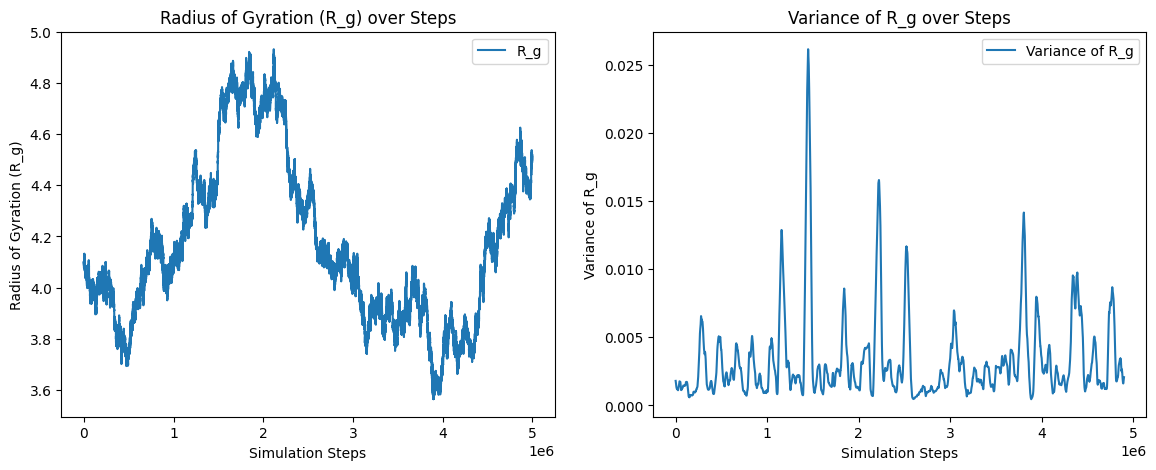

nu = 0.4: Mean R_g = 4.1682, Variance R_g = 0.1034


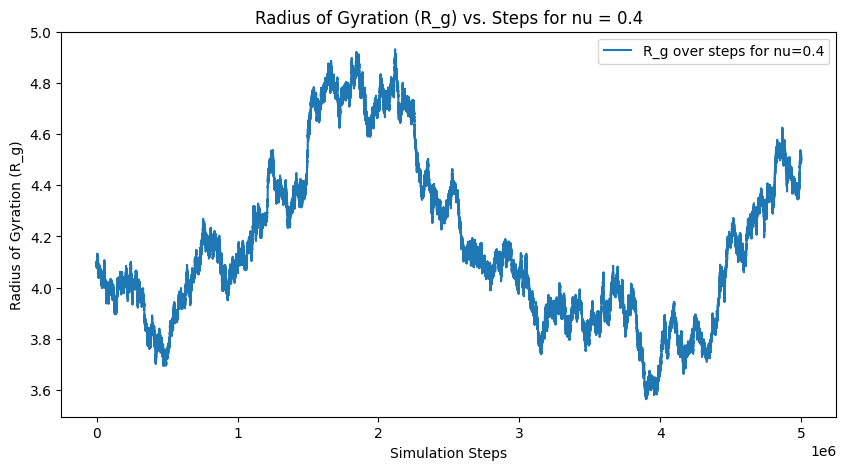

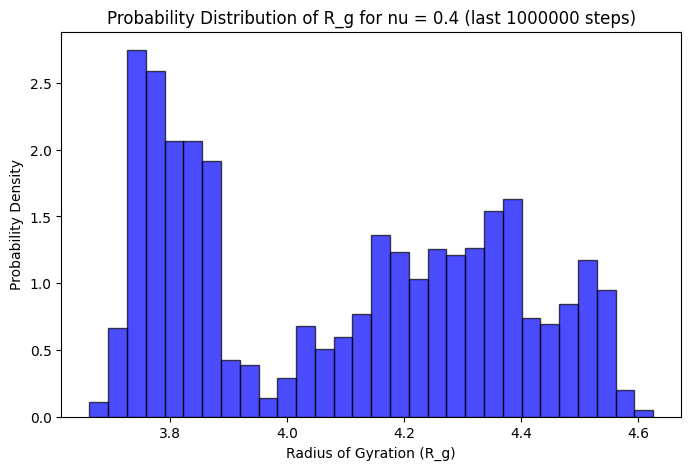


Running simulation for nu = 0.5
Step: 0, R_g: 3.8732
Step: 100, R_g: 3.8832
Step: 200, R_g: 3.8821
Step: 300, R_g: 3.8828
Step: 400, R_g: 3.8816
Step: 500, R_g: 3.8732
Step: 600, R_g: 3.8724
Step: 700, R_g: 3.8621
Step: 800, R_g: 3.8570
Step: 900, R_g: 3.8494
Step: 1000, R_g: 3.8336
Step: 1100, R_g: 3.8349
Step: 1200, R_g: 3.8346
Step: 1300, R_g: 3.8226
Step: 1400, R_g: 3.8182
Step: 1500, R_g: 3.8247
Step: 1600, R_g: 3.8263
Step: 1700, R_g: 3.8251
Step: 1800, R_g: 3.8337
Step: 1900, R_g: 3.8362
Step: 2000, R_g: 3.8325
Step: 2100, R_g: 3.8317
Step: 2200, R_g: 3.8289
Step: 2300, R_g: 3.8304
Step: 2400, R_g: 3.8299
Step: 2500, R_g: 3.8369
Step: 2600, R_g: 3.8447
Step: 2700, R_g: 3.8428
Step: 2800, R_g: 3.8443
Step: 2900, R_g: 3.8407
Step: 3000, R_g: 3.8477
Step: 3100, R_g: 3.8475
Step: 3200, R_g: 3.8429
Step: 3300, R_g: 3.8388
Step: 3400, R_g: 3.8396
Step: 3500, R_g: 3.8232
Step: 3600, R_g: 3.8249
Step: 3700, R_g: 3.8229
Step: 3800, R_g: 3.8160
Step: 3900, R_g: 3.8189
Step: 4000, R_g: 3.

KeyboardInterrupt: 

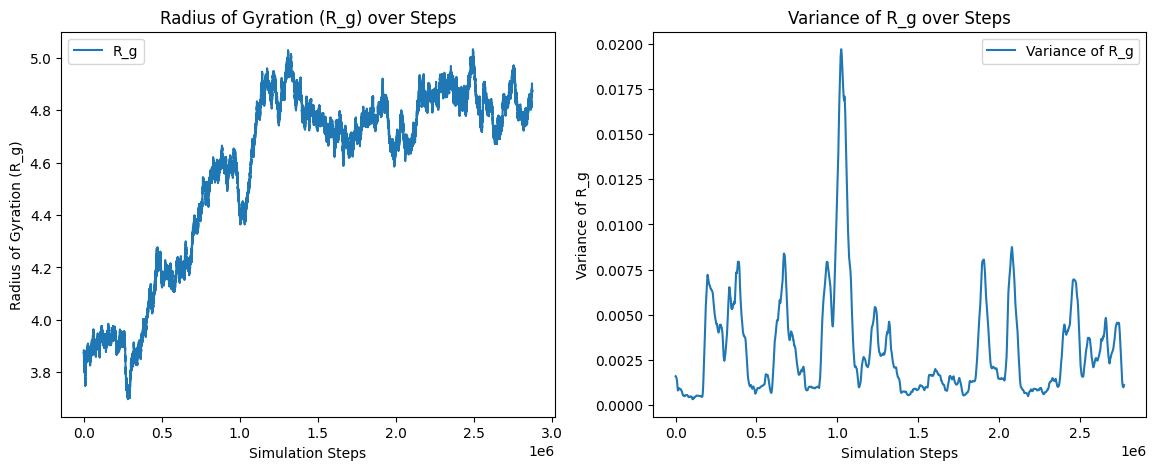

In [27]:
# Run the simulations over the range of nu values
run_simulations_over_nu_range(nu_values, N, num_steps, window_size=window_size, pdf_sample_size=1000000)